## Processamento de Linguagem Natural - Lista 01

Alunos
- Arthur Pontes de Miranda Ramos Soares
- Beatriz Rodrigues Cavalcante

In [ ]:

import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd

nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('tagsets')

from collections import Counter

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.lancaster import LancasterStemmer
from nltk.tag import pos_tag
from sklearn.feature_extraction.text import CountVectorizer


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!


In [ ]:
# Fetch data from github
!mkdir -p assets
!wget -q "https://raw.githubusercontent.com/Arthurpmrs/nlp-numerical-methods/refs/heads/main/nlp/data/songs_reduced.csv?raw=true" -O ./assets/songs_reduced.csv

## Questão 01

Escreva uma função que recebe uma senha como entrada e verifica se ela atende aos seguintes crit ́erios de uma senha forte:
- Pelo menos 8 caracteres
- Pelo menos uma letra maíuscula e uma letra minúscula
- Pelo menos um dígito
- Pelo menos um caractere especial (por exemplo, !@#$%&*)

A função deve retornar True se a senha for forte e False caso contrário. Mostre exemplos.

In [ ]:
patterns = (
    re.compile(r'[A-Z]'),
    re.compile(r'[a-z]'),
    re.compile(r'[0-9]'),
    re.compile(r'[!@#$%&*_]'),
)

def is_password_strong(password: str) -> bool:
    if len(password) < 8:
        return False

    matching = [pattern.search(password) is not None for pattern in patterns]

    return all(matching)

def is_password_strong_no_regex(password: str) -> bool:
    if len(password) < 8:
        return False

    checks = (
        any(l.isdigit() for l in password),
        any(l.islower() for l in password),
        any(l.isupper() for l in password),
        any(l in '!@#$%&*_' for l in password)
    )

    return all(checks)

In [ ]:
passwords = ["abcdef", "123456", "apenasumasenha", "APENASUMASENHA", "SENHA98SENHA_", "UmaSenhaBoa", "Senha78Minha", "!S3nh490Bo$a"]

print("Usando REGEX")

for password in passwords:
    print({"senha": password, "forte": is_password_strong(password)})

print("\nIterando diretamente na string e usando métodos do Python")

for password in passwords:
    print({"senha": password, "forte": is_password_strong_no_regex(password)})

Usando REGEX
{'senha': 'abcdef', 'forte': False}
{'senha': '123456', 'forte': False}
{'senha': 'apenasumasenha', 'forte': False}
{'senha': 'APENASUMASENHA', 'forte': False}
{'senha': 'SENHA98SENHA_', 'forte': False}
{'senha': 'UmaSenhaBoa', 'forte': False}
{'senha': 'Senha78Minha', 'forte': False}
{'senha': '!S3nh490Bo$a', 'forte': True}

Iterando diretamente na string e usando métodos do Python
{'senha': 'abcdef', 'forte': False}
{'senha': '123456', 'forte': False}
{'senha': 'apenasumasenha', 'forte': False}
{'senha': 'APENASUMASENHA', 'forte': False}
{'senha': 'SENHA98SENHA_', 'forte': False}
{'senha': 'UmaSenhaBoa', 'forte': False}
{'senha': 'Senha78Minha', 'forte': False}
{'senha': '!S3nh490Bo$a', 'forte': True}


## Questão 2

A questão pede para usar regex para criar uma função que checa se o email é válido. A expressão regular usada para validar foi:

```js
^[a-zA-Z](?:[\w._%+-]*[\w])?@(?:[\w](?:[\w-]*[\w])?\.)+[a-zA-Z]{2,}$
```

Jogando esse regex no site [regexplained](https://www.regexplained.co.uk/) é possível ver o fluxograma da expressão regular, que ajuda a entender como ela funciona. As regras usadas foi:
- No início, o email deve começar com uma letra. Em seguida, pode ter letras, números, pontos, sublinhados, porcentagens, sinais de mais ou hífens. No entanto, não pode terminar com esses caracteres especiais.
- Depois do símbolo `@`, o domínio deve começar com uma letra ou número, seguido de letras, números ou hífens. O domínio pode ter subdomínios, separados por pontos.
- O domínio de nível superior (TLD) deve ter pelo menos duas letras.
- É possível ter subdomínios, mas não é obrigatório. O domínio principal e os subdomínios devem seguir as mesmas regras de caracteres permitidos.

In [ ]:
def is_valid_email(email:str) -> bool:
    match = re.fullmatch(
        r"^[a-zA-Z](?:[\w.%+-]*[\w])?@(?:[a-zA-Z](?:[\w-]*[\w])?\.)+[a-zA-Z]{2,}$",
        email,
    )
    return match != None

emails_list = [
    "test@example.com",
    "user@domain.org",
    "user@domain.org blablabla",
    "test",
    "user.name+tag@sub.domain.com",
    "user_name@domain.co",
    "123@456.com",
    "a@b.io",
    "user@domain",
    "user@.com",
    "@domain.com",
    "user domain@example.com",
    "user@domain..com",
    "user@-domain.com",
    "user@domain-.com",
    ".user@example.com",
    "user.@example.com",
    "user..name@example.com",
    "user@@domain.com",
    "user@mail.sub.example.com",
    "user@domain.c",
    "",
]

for email in emails_list:
    res = is_valid_email(email)
    print("email: ", email, "\ncheck: ", res)
    print()

email:  test@example.com 
check:  True

email:  user@domain.org 
check:  True

email:  user@domain.org blablabla 
check:  False

email:  test 
check:  False

email:  user.name+tag@sub.domain.com 
check:  True

email:  user_name@domain.co 
check:  True

email:  123@456.com 
check:  False

email:  a@b.io 
check:  True

email:  user@domain 
check:  False

email:  user@.com 
check:  False

email:  @domain.com 
check:  False

email:  user domain@example.com 
check:  False

email:  user@domain..com 
check:  False

email:  user@-domain.com 
check:  False

email:  user@domain-.com 
check:  False

email:  .user@example.com 
check:  False

email:  user.@example.com 
check:  False

email:  user..name@example.com 
check:  True

email:  user@@domain.com 
check:  False

email:  user@mail.sub.example.com 
check:  True

email:  user@domain.c 
check:  False

email:   
check:  False



## Questão 3

Considere o seguinte exemplo de referência de livro em formato de
citação APA:

Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of
statistical natural language processing. MIT press. *italicised text*

Implemente uma função usando expressões regulares que extraia cada autor, ano de publicação, tı́tulo e editora do livro, para qualquer referência de livro neste formato.

In [ ]:
def get_reference_data(reference: str) -> dict:
    data = {}

    author_pattern = re.compile(r"([a-zA-Z]+),\s((?:[A-Z]\.\s?)+)")
    authors_result = author_pattern.findall(reference)
    data.update({"authors": [f"{ar[1]} {ar[0]}" for ar in authors_result]})


    remaining_pattern = re.compile(r"\((\d{4})\)\.\s*(.*?)\.\s*(.*?)\.")
    result = remaining_pattern.search(reference)

    if result is None:
        raise Exception("Referência incorreta.")

    year, title, publisher = result.groups()

    data.update({
        "year": int(year),
        "title": title,
        "publisher": publisher
    })

    return data

In [ ]:
reference = "Manning, C. D., Manning, C. D., & Schutze, H. (1999). Foundations of statistical natural language processing. MIT press."

data = get_reference_data(reference)
print(data)

{'authors': ['C. D. Manning', 'C. D. Manning', 'H.  Schutze'], 'year': 1999, 'title': 'Foundations of statistical natural language processing', 'publisher': 'MIT press'}


## Questão 4

A questão pede para contar o tamanho dos textos e plotar um histograma com a distribuição dos tamanhos. Foi retirado os tokens da coluna `lyrics` e calculado o tamanho de cada texto, aplicando o `len`. Após isso, foi plotado o histograma com a função `hist` do matplotlib.

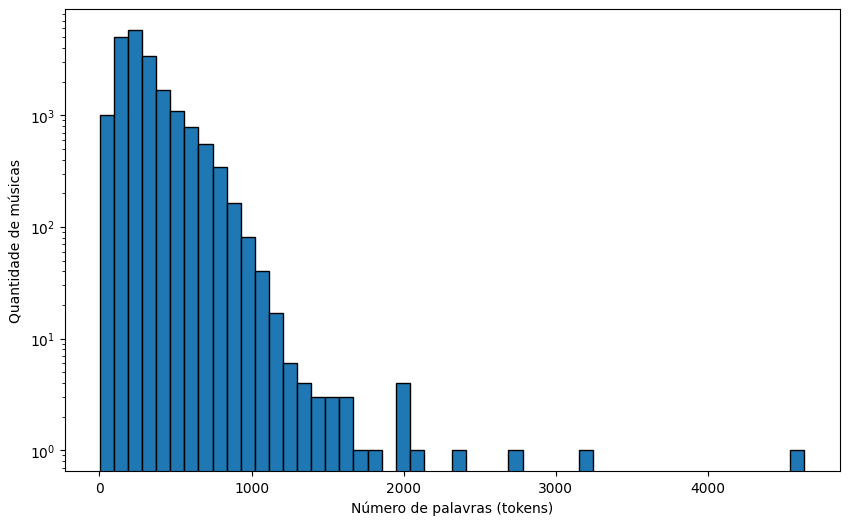

In [ ]:
original = pd.read_csv("assets/songs_reduced.csv")
tokens = original["lyrics"].str.split()
word_count = tokens.apply(len)

plt.figure(figsize=(10, 6))
plt.hist(word_count, bins=50, edgecolor='black')
plt.yscale('log')
plt.xlabel('Número de palavras (tokens)')
plt.ylabel('Quantidade de músicas')
plt.show()

## Questão 5
Aplique os seguintes passos de pré-processamento aos textos:

- Remova todas as palavras que contêm números;
- Converta as palavras para minúsculas;
- Remova pontuação;
- Tokenize os textos em palavras, gerando um dicionário único com n tokens e convertendo cada texto em um vetor de dimensão n com a respectiva contagem de palavras.

Em seguida, encontre as 10 palavras mais frequentes da base de textos.

In [ ]:
def preprocess_lyrics(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r"\b\w*\d\w*\b", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
original = pd.read_csv("assets/songs_reduced.csv")
original['lyrics'] = original['lyrics'].apply(preprocess_lyrics)
original["tokens"] = original["lyrics"].str.split()
original[['genre', 'lyrics', 'tokens']]

,genre,lyrics,tokens
0,Hip-Hop,snow flakes in january heart warm like februar...,"[snow, flakes, in, january, heart, warm, like,..."
1,Country,it was july hot in georgia in all the men were...,"[it, was, july, hot, in, georgia, in, all, the..."
2,Hip-Hop,i see your face cloud over like a little girls...,"[i, see, your, face, cloud, over, like, a, lit..."
3,Country,come close just look at me can you see that ne...,"[come, close, just, look, at, me, can, you, se..."
4,Pop,girls in america girls in america go another b...,"[girls, in, america, girls, in, america, go, a..."
...,...,...,...
19995,Hip-Hop,it dont take much strength to pull a trigger b...,"[it, dont, take, much, strength, to, pull, a, ..."
19996,Hip-Hop,she can walk that walk walk that walk walk tha...,"[she, can, walk, that, walk, walk, that, walk,..."
19997,Folk,they told him dont you ever come around here d...,"[they, told, him, dont, you, ever, come, aroun..."
19998,Country,so many times i tried to give you what you sai...,"[so, many, times, i, tried, to, give, you, wha..."


In [ ]:
def get_bow(token_column, n_most_commons: float = 4000) -> pd.DataFrame:
    """
    Gera matriz cujas colunas são as palavras e as linhas representam
    a contagem de palavras nos textos.

    Foi necessário reduzir a quantidade de palavras pegando as n mais comuns,
    por questão de limitação de memória.
    """
    all_tokens = token_column.explode()
    token_counts = Counter(token for token in all_tokens).most_common()
    top_tokens = token_counts[:n_most_commons]
    vocab = {token for token, count in top_tokens}

    filtered_tokens = all_tokens[all_tokens.isin(vocab)]
    bow = pd.crosstab(filtered_tokens.index, pd.Categorical(filtered_tokens, categories=list(vocab)))
    bow = bow.reindex(original.index, fill_value=0)

    return bow

In [ ]:
bow = get_bow(original['tokens'], 6000)

In [ ]:
# Dicionário com frequência de palalvras
print(bow.shape)
bow

(20000, 6000)


col_0,clover,grab,thuggin,raised,cuts,florida,pullin,cursed,gamble,en,...,vomit,passes,hands,pm,lawyers,c,draco,caress,ann,collect
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19996,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Palavras mais comuns
bow.sum(axis=0).sort_values(ascending=False).head(10)

,0
col_0,
the,233541
i,191137
you,171971
and,128535
a,124823
to,117862
me,88399
my,84150
in,78492


## Questão 6

A questão pede para aplicar mais passos de pré-processamento nos tokens gerados na questão anterior: remoção de stopwords, rotulação de classes gramaticais (POS tagging) e stemização. Foi criada uma coluna no dataframe para cada um desses passos:

- `tokens_no_stop`: tokens da questão anterior sem as stopwords do inglês (lista do NLTK).
- `pos_tags`: cada token de `tokens_no_stop` rotulado com sua classe gramatical, usando o `pos_tag` do NLTK.
- `tokens_stemmed`: tokens de `tokens_no_stop` reduzidos ao radical, usando o `LancasterStemmer`.

In [ ]:
en_stopwords_set = set(stopwords.words('english'))

original['tokens_no_stop'] = original['tokens'].apply(
    lambda tokens: [t for t in tokens if t not in en_stopwords_set]
)


In [ ]:
original['pos_tags'] = original['tokens_no_stop'].apply(pos_tag)


In [ ]:
stemmer = LancasterStemmer()
original['tokens_stemmed'] = original['tokens_no_stop'].apply(
    lambda tokens: [stemmer.stem(t) for t in tokens]
)


### a) Resultados em alguns textos

Abaixo é possível comparar, para as primeiras músicas da base, o resultado de cada etapa do pré-processamento lado a lado: os tokens originais, os tokens sem stopwords, os tokens stemizados e as tags POS atribuídas a cada palavra.

In [ ]:
original[['tokens', 'tokens_no_stop', 'tokens_stemmed', 'pos_tags']].head()

,tokens,tokens_no_stop,tokens_stemmed,pos_tags
0,"[snow, flakes, in, january, heart, warm, like,...","[snow, flakes, january, heart, warm, like, feb...","[snow, flak, janu, heart, warm, lik, febru, wo...","[(snow, NN), (flakes, NNS), (january, JJ), (he..."
1,"[it, was, july, hot, in, georgia, in, all, the...","[july, hot, georgia, men, war, women, nothing,...","[july, hot, georg, men, war, wom, noth, hungry...","[(july, NN), (hot, JJ), (georgia, JJ), (men, N..."
2,"[i, see, your, face, cloud, over, like, a, lit...","[see, face, cloud, like, little, girls, eyes, ...","[see, fac, cloud, lik, littl, girl, ey, lost, ...","[(see, VB), (face, JJ), (cloud, NNS), (like, I..."
3,"[come, close, just, look, at, me, can, you, se...","[come, close, look, see, new, england, breeze,...","[com, clos, look, see, new, england, breez, bl...","[(come, VBN), (close, JJ), (look, NNS), (see, ..."
4,"[girls, in, america, girls, in, america, go, a...","[girls, america, girls, america, go, another, ...","[girl, americ, girl, americ, go, anoth, blurry...","[(girls, NNS), (america, VBP), (girls, NNS), (..."


### b) 10 palavras mais frequentes (sem stopwords) x questão anterior

Na questão 5, sem remover stopwords, as palavras mais frequentes eram artigos, pronomes e preposições comuns em inglês (`the`, `i`, `you`, `and`, `a`, `to`, `me`, `my`, `in`, `it`), o que não traz muita informação sobre o conteúdo das letras.

Depois de remover as stopwords, o top 10 passa a ser composto por gírias e palavras mais características de letras de música (`im`, `like`, `dont`, `know`, `love`, `got`, `yeah`, `get`, `oh`, `go`). Isso mostra que remover stopwords ajuda a filtrar palavras puramente gramaticais e destacar termos que carregam mais significado no conteúdo das músicas.

In [ ]:
all_tokens_no_stop = [token for tokens in original['tokens_no_stop'] for token in tokens]
freq_no_stop = Counter(all_tokens_no_stop)

pd.DataFrame(freq_no_stop.most_common(10), columns=['palavra', 'contagem'])

,palavra,contagem
0,im,54761
1,like,37978
2,dont,35714
3,know,32432
4,love,29981
5,got,26472
6,yeah,25683
7,get,24325
8,oh,22533
9,go,20187


### c) 10 palavras mais frequentes (tokens stemizados)

O ranking das palavras mais frequentes usando os tokens stemizados é bem parecido com o do item anterior. A principal diferença é que radicais diferentes que compartilham o mesmo stem passam a ser contados juntos (por exemplo, `come`, `coming` e `comes` viram todos `com`), o que pode aumentar a contagem de algumas palavras e até mudar sua posição no ranking, como aconteceu com `com`, que entra no top 10 no lugar de `go`.

In [ ]:
all_tokens_stemmed = [token for tokens in original['tokens_stemmed'] for token in tokens]
freq_stemmed = Counter(all_tokens_stemmed)

pd.DataFrame(freq_stemmed.most_common(10), columns=['palavra', 'contagem'])

,palavra,contagem
0,im,57203
1,lik,38486
2,dont,35721
3,lov,34886
4,know,34700
5,get,27804
6,got,26697
7,yeah,25693
8,oh,22542
9,com,20694


### d) Classes gramaticais mais frequentes

A classe gramatical mais frequente é `NN` (substantivo comum, singular), seguida por `JJ` (adjetivo) e `NNS` (substantivo comum, plural).

In [ ]:
tagdict = nltk.data.load('help/tagsets/upenn_tagset.pickle')
tag_description = {tag: tagdict[tag][0] for tag in tagdict}

all_tags = [tag for pos_list in original['pos_tags'] for word, tag in pos_list]
freq_tags = Counter(all_tags)

top_tags = pd.DataFrame(freq_tags.most_common(10), columns=['tag', 'contagem'])
top_tags['descricao'] = top_tags['tag'].map(tag_description)
top_tags

,tag,contagem,descricao
0,NN,1213982,"noun, common, singular or mass"
1,JJ,578520,"adjective or numeral, ordinal"
2,NNS,256596,"noun, common, plural"
3,VBP,249153,"verb, present tense, not 3rd person singular"
4,RB,191654,adverb
5,VB,145163,"verb, base form"
6,VBD,136343,"verb, past tense"
7,VBG,105460,"verb, present participle or gerund"
8,IN,83851,"preposition or conjunction, subordinating"
9,VBN,68252,"verb, past participle"
